# Fifth Question
In question 4, piecharts were created. But they displayed all accumulated reports in the dataset. It would be useful to see if the distribution of the reports per category changes over time. Thats why my fifth question is: "How has the number of reports per category developed over time?". 

I want to answer this question by creating a linegraph.

## Workflow
1. Think about additional attributes needed
2. reuse code
3. Sum up report numbers per time
4. plot number of reports of one category
5. adjust code so that all categorys are plotted
6. Create funktion to use code on different neighbouhoods

### 1. Additional attributes needed

| Name | Definition |
|------|------------|
| REQUESTED_DATETIME | Datum und Zeitpunkt an welchem die Meldung erstellt wurde [DD.MM.YYYY HH:MM:SS] Original: The date and time when the service request was made. Typ DATE. |

### 2. Reuse Code
Add "requested_datetime" to the filter

In [1]:
# Code from question 3 and 4

# Load Librarys
import pandas as pd
import geopandas as gpd 
import numpy as np
import matplotlib.pyplot as plt

# Load data
data_gpkg = gpd.read_file("../data/raw/ZuriWieNeu_gpkg_data/data.gpkg").to_crs(epsg=2056)
boundaries_gpkg_v = gpd.read_file("../data/raw/boundaries_GPKG/data.gpkg",
 layer="stzh.adm_statistische_quartiere_v").to_crs(epsg=2056) 

# Filter data
data_subset = data_gpkg[["geometry", "service_code", "requested_datetime"]]
boundaries_subset = boundaries_gpkg_v[["geometry", "qname"]]

# Spatial Join: distribute points to neighbourhoods
joined = gpd.sjoin(data_subset, boundaries_subset, how= "left", predicate="within")


## 3. Sum up report numbers per time


First I needed to know how long the timeseries is by looking at the first and the last date.

In [2]:
# check that that time data is in datetime
joined["requested_datetime"] = pd.to_datetime(joined["requested_datetime"])

# first and last date
first_date = joined["requested_datetime"].min()
last_date = joined["requested_datetime"].max()

print("First report:", first_date)
print("Last report:", last_date)


First report: 2013-03-14 15:16:15
Last report: 2026-05-15 16:43:35


Make new year collumn for grouping

In [ ]:
# new collumn with year
joined["year"] = joined["requested_datetime"].dt.year


Grouping

In [ ]:
# Count Numbers of reports per neighbourhood per category per year
counts = (
    joined
    .groupby(["qname", "service_code", "year"])
    .size()
    .reset_index(name="n_reports")
)
counts

,qname,service_code,year,n_reports
0,Affoltern,Abfall/Sammelstelle,2013,23
1,Affoltern,Abfall/Sammelstelle,2014,22
2,Affoltern,Abfall/Sammelstelle,2015,16
3,Affoltern,Abfall/Sammelstelle,2016,23
4,Affoltern,Abfall/Sammelstelle,2017,37
...,...,...,...,...
3889,Wollishofen,VBZ/ÖV,2022,3
3890,Wollishofen,VBZ/ÖV,2023,5
3891,Wollishofen,VBZ/ÖV,2024,20
3892,Wollishofen,VBZ/ÖV,2025,9


## 4. plot number of reports of one category in one neighbourhood
Selected neighbourhood: Affoltern

Selected category: Abfall/Sammelstelle

In [8]:
# Filter for Affoltern and Abfall/Sammelstelle
affoltern_abfall = counts[
    (counts["qname"] == "Affoltern") & 
    (counts["service_code"] == "Abfall/Sammelstelle")]


affoltern_abfall

,qname,service_code,year,n_reports
0,Affoltern,Abfall/Sammelstelle,2013,23
1,Affoltern,Abfall/Sammelstelle,2014,22
2,Affoltern,Abfall/Sammelstelle,2015,16
3,Affoltern,Abfall/Sammelstelle,2016,23
4,Affoltern,Abfall/Sammelstelle,2017,37
5,Affoltern,Abfall/Sammelstelle,2018,41
6,Affoltern,Abfall/Sammelstelle,2019,55
7,Affoltern,Abfall/Sammelstelle,2020,65
8,Affoltern,Abfall/Sammelstelle,2021,77
9,Affoltern,Abfall/Sammelstelle,2022,65


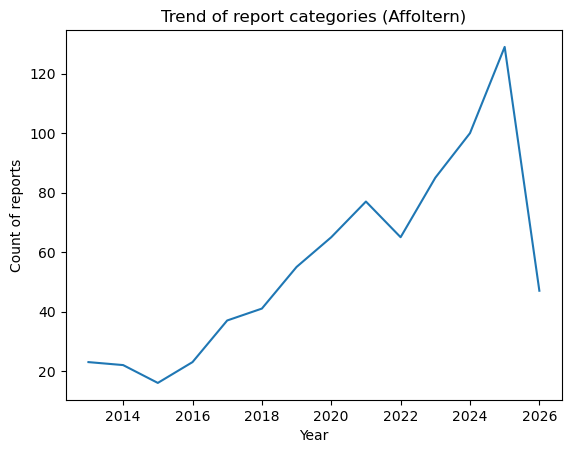

In [11]:
# Plot

# create figure and ax
fig, ax = plt.subplots()

# plotline
ax.plot(affoltern_abfall["year"], affoltern_abfall["n_reports"])
ax.set_title("Trend of report categories (Affoltern)")
ax.set_ylabel("Count of reports")
ax.set_xlabel("Year")
plt.show()


## 5. adjust code so that all categorys are plotted

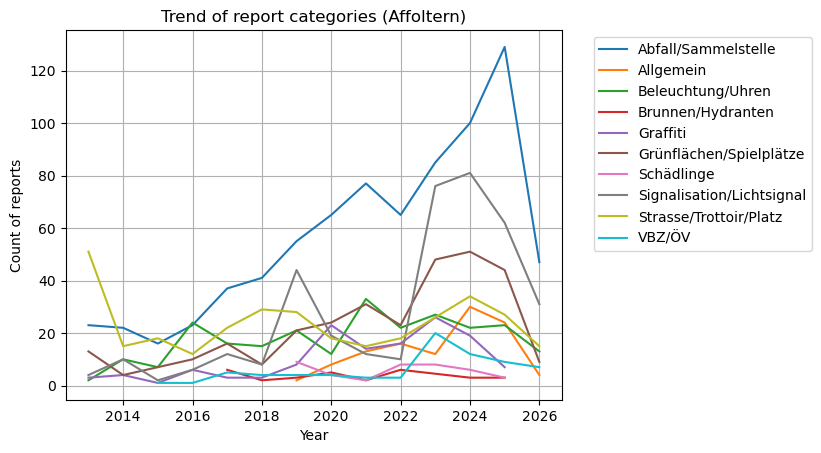

In [ ]:
# Plot
# Filter for Affoltern only
affoltern = counts[counts["qname"] == "Affoltern"]

# create figure and ax
fig, ax = plt.subplots()

# Plot a line for each category (for loop)
for service_code, group in affoltern.groupby("service_code"):
    ax.plot(group["year"], group["n_reports"], label=service_code)

ax.set_title("Trend of report categories (Affoltern)")
ax.set_ylabel("Count of reports")
ax.set_xlabel("Year")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid() == True
plt.show()


## 6. Create function to use code on different neighbouhoods

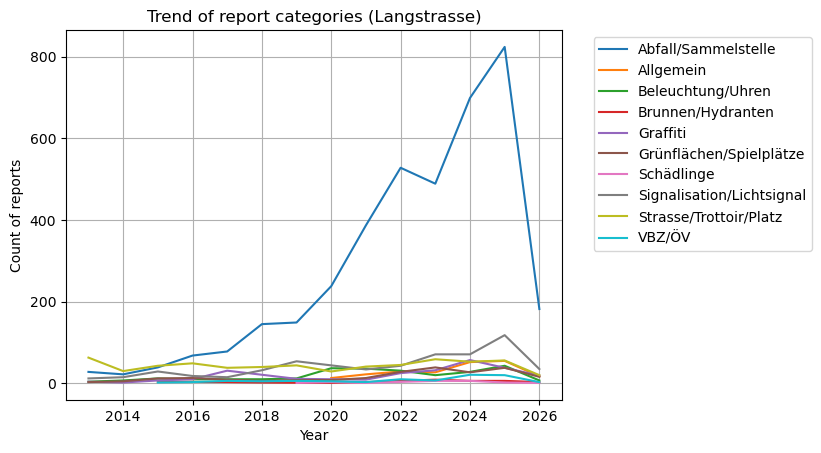

In [ ]:
def plot_category_trends(counts, qname):
    # Filter for the neighborhood
    neighborhood = counts[counts["qname"] == qname]

    # Create figure and ax
    fig, ax = plt.subplots()

    # Plot a line for each category
    for service_code, group in neighborhood.groupby("service_code"):
        ax.plot(group["year"], group["n_reports"], label=service_code)

    ax.set_title(f"Trend of report categories ({qname})")
    ax.set_ylabel("Count of reports")
    ax.set_xlabel("Year")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid() == True
    plt.show()

# check function
plot_category_trends(counts, "Langstrasse")